# TS7 - Filtrado digital lineal de ECG

Senal: `ecg.mat` - registro electrocardiografico de una prueba de esfuerzo, $f_s = 1\,\text{kHz}$, $\approx 18.8$ min.

Fuentes de contaminacion a mitigar
- Ruido por movimiento de electrodos y ruido muscular (EMG) -> alta frecuencia.
- Movimiento de la linea de base inducido por la respiracion -> baja frecuencia.

In [18]:
import numpy as np
import scipy.io as sio
import scipy.signal as sig
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})


In [19]:
mat = sio.loadmat('ecg.mat')

fs           = 1000
ecg_lead     = mat['ecg_lead'].flatten().astype(float)
qrs_pattern1 = mat['qrs_pattern1'].flatten()
hb_normal    = mat['heartbeat_pattern1'].flatten().astype(float)
hb_ventri    = mat['heartbeat_pattern2'].flatten().astype(float)
qrs_det      = mat['qrs_detections'].flatten()

cant_muestras = len(ecg_lead)
t = np.arange(cant_muestras) / fs
print(f'ECG: N={cant_muestras} muestras  ->  {cant_muestras/fs/60:.2f} min   (fs={fs} Hz)')
print(f'Latidos detectados (qrs_detections): {len(qrs_det)}')


ECG: N=1129116 muestras  ->  18.82 min   (fs=1000 Hz)
Latidos detectados (qrs_detections): 1903


## a) Plantilla de diseno

Se disena un filtro pasa-banda con tres zonas:

1. Stopband inferior $[0,\ \omega_{s1}]$ -> elimina la deriva de linea de base (respiracion).
2. Banda de paso $[\omega_{p1},\ \omega_{p2}]$ -> preserva el complejo QRS y la parte central del ECG.
3. Stopband superior $[\omega_{s2},\ f_s/2]$ -> elimina el ruido muscular y de electrodos.

| Parametro | Valor | Justificacion |
|:--|:--:|:--|
| `ws1` | 2 Hz | Borde superior del stopband inferior. La deriva respiratoria (0.15-0.4 Hz) y la baja frecuencia quedan atenuadas $\ge 40$ dB. |
| `wp1` | 5 Hz | Borde inferior de la banda de paso. Asegura un nivel isoelectrico plano (linea de base nula). |
| `wp2` | 25 Hz | Borde superior de la banda de paso. Cubre el grueso de la energia del ECG (BW-95% ~ 22 Hz, ver abajo) y suaviza los trazos. |
| `ws2` | 35 Hz | Borde inferior del stopband superior. Atenua EMG y artefactos de electrodos, dejando una transicion de 10 Hz. |

 

| Especificacion de amplitud | Valor |
|:--|:--:|
| Rizado en banda de paso (`gpass`) | 1 dB |
| Atenuacion en stopbands (`gstop`) | 40 dB |

In [20]:
nyq_frec   = fs / 2
ripple     = 1
atenuacion = 40

ws1 = 2.0
wp1 = 5.0
wp2 = 25.0
ws2 = 35.0

frecs = np.array([0.0,         ws1,         wp1,     wp2,     ws2,         nyq_frec   ]) / nyq_frec
gains = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])

gains_lin = 10 ** (gains / 20)

print(f'Banda de paso     : [{wp1}, {wp2}] Hz')
print(f'Stopband inferior : [0, {ws1}] Hz')
print(f'Stopband superior : [{ws2}, {nyq_frec:.0f}] Hz')


Banda de paso     : [5.0, 25.0] Hz
Stopband inferior : [0, 2.0] Hz
Stopband superior : [35.0, 500] Hz


Verificacion del ancho de banda. Reaplicamos el metodo de Welch sobre el
registro real para fijar `wp2`: la frecuencia por debajo de la cual se acumula una fraccion de la
potencia total.

In [21]:
f_w, Pxx = sig.welch(ecg_lead - ecg_lead.mean(), fs=fs,
                     window='hann', nperseg=4096, noverlap=2048)
P_cum = np.cumsum(Pxx) * (f_w[1] - f_w[0])
P_cum /= P_cum[-1]

for p in (0.90, 0.95, 0.99):
    f_bw = f_w[np.searchsorted(P_cum, p)]
    print(f'BW {int(p*100)}% de potencia : {f_bw:5.1f} Hz')

print(f'\n-> wp2 = {wp2} Hz cubre el BW-95% del ECG; se prioriza la suavidad de los trazos.')


BW 90% de potencia :  18.1 Hz
BW 95% de potencia :  22.0 Hz
BW 99% de potencia :  31.0 Hz

-> wp2 = 25.0 Hz cubre el BW-95% del ECG; se prioriza la suavidad de los trazos.


Latidos promediados: 1588 normales, 315 ventriculares


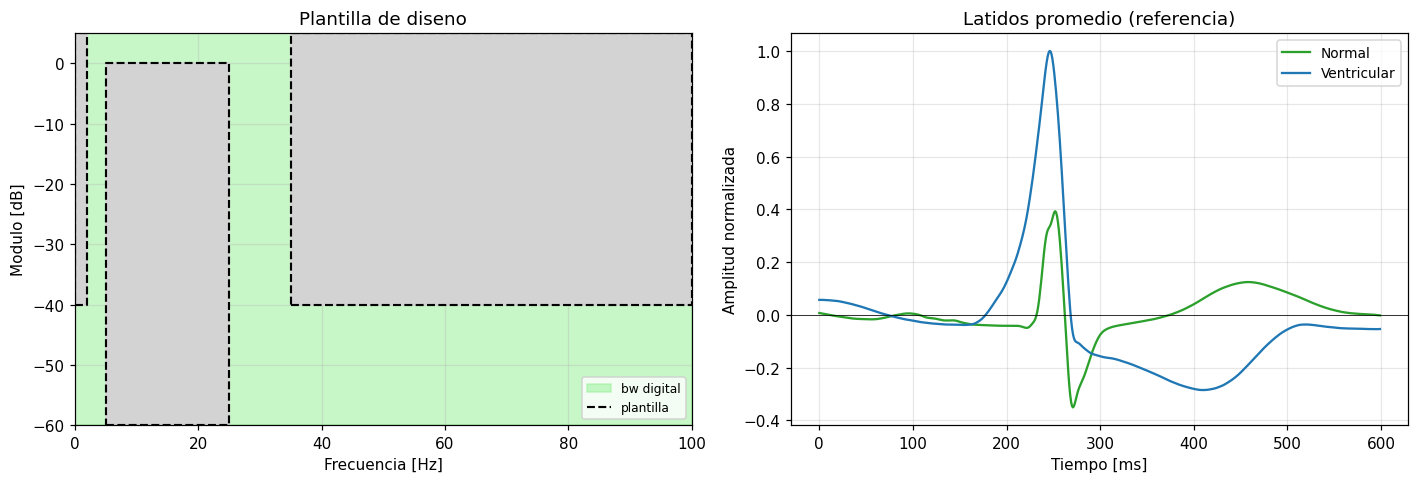

In [22]:
pre, post = 250, 350
W = pre + post
r1, r2 = hb_normal.argmax(), hb_ventri.argmax()

def _alinear(p, r):
    c = np.zeros(W); s = pre - r
    a, b = max(0, s), min(W, s + len(p))
    c[a:b] = p[a-s:b-s]
    return c

tmpl_n, tmpl_v = _alinear(hb_normal, r1), _alinear(hb_ventri, r2)

def _ncc(a, b):
    a = a - a.mean(); b = b - b.mean()
    return (a @ b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

beats = []
for d in qrs_det.astype(int):
    a, b = d - pre, d + post
    if a < 0 or b > cant_muestras:
        continue
    seg = ecg_lead[a:b].copy()
    beats.append(seg - np.mean(np.r_[seg[:30], seg[-30:]]))
beats = np.array(beats)

es_ventri  = np.array([_ncc(s, tmpl_v) > _ncc(s, tmpl_n) for s in beats])
lat_normal = beats[~es_ventri].mean(0)
lat_ventri = beats[ es_ventri].mean(0)
esc = max(np.abs(lat_normal).max(), np.abs(lat_ventri).max())
lat_normal /= esc; lat_ventri /= esc
t_lat = np.arange(W)

print(f'Latidos promediados: {np.sum(~es_ventri)} normales, {np.sum(es_ventri)} ventriculares')

fig, (axp, axb) = plt.subplots(1, 2, figsize=(13, 4.5))

floor, ytop, f_lim = -60, 5, 100
axp.fill_between([0, f_lim], floor, ytop, color='lightgreen', alpha=0.5, label='bw digital')
zonas = [(0,    ws1,   -atenuacion,  ytop),
         (wp1,  wp2,    floor,        0.0),
         (ws2,  f_lim, -atenuacion,  ytop)]
for x0, x1, y0, y1 in zonas:
    axp.fill_between([x0, x1], y0, y1, color='lightgray', zorder=2)
    axp.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], 'k--', lw=1.4, zorder=3)
axp.plot([], [], 'k--', lw=1.4, label='plantilla')
axp.set(title='Plantilla de diseno', xlabel='Frecuencia [Hz]', ylabel='Modulo [dB]',
        xlim=(0, f_lim), ylim=(floor, ytop))
axp.grid(alpha=0.3); axp.legend(fontsize=8, loc='lower right')

axb.plot(t_lat, lat_normal, color='C2', label='Normal')
axb.plot(t_lat, lat_ventri, color='C0', label='Ventricular')
axb.axhline(0, color='k', lw=0.5)
axb.set(title='Latidos promedio (referencia)', xlabel='Tiempo [ms]', ylabel='Amplitud normalizada')
axb.grid(alpha=0.3); axb.legend(fontsize=9)

plt.tight_layout(); plt.show()


## b) Procedimiento para establecer los valores de la plantilla

Los cuatro bordes se fijaron combinando el resultado espectral de TS5 (recalculado arriba sobre la
senal real) con el conocimiento fisiologico del ECG y de las interferencias.

Banda de paso `[wp1=5, wp2=25]` Hz - preservar el complejo QRS y suavizar
- `wp2 = 25 Hz`: el criterio de contenido de potencia (Welch, TS5) ubica el 95 % de la potencia por
  debajo de ~22 Hz. Tomar 25 Hz cubre esa energia y, al recortar por encima, suaviza los trazos
  (objetivo del punto a), a costa de redondear levemente las componentes mas rapidas del QRS.
- `wp1 = 5 Hz`: un borde de paso relativamente alto fuerza un nivel isoelectrico plano, eliminando
  toda la deriva lenta. (Es un compromiso: cuanto mas alto wp1, mas plana la linea de base pero mayor la
  atenuacion de las ondas lentas P y T.)

Stopband inferior `[0, ws1=2]` Hz - eliminar deriva de linea de base
- La respiracion (0.2-0.4 Hz) y la deriva lenta quedan a >= 40 dB. `ws1 = 2 Hz` deja una banda de
  transicion de 3 Hz hacia `wp1`, suficientemente ancha para ordenes de filtro razonables.

Stopband superior `[ws2=35, fs/2]` Hz - eliminar EMG y ruido de electrodos
- El ruido muscular y los artefactos de movimiento dominan por encima de ~35 Hz. `ws2 = 35 Hz` deja una
  transicion de 10 Hz (25->35 Hz), comoda para el diseno.

Amplitudes: `gpass = 1 dB` (perdida < 11 % en banda de paso) y `gstop = 40 dB`
(interferencias reducidas 100x en amplitud).

## c) Diseno de filtros IIR y FIR

Se disenan 3 filtros IIR (maxima planicidad, Chebyshev y Cauer) y 3 FIR (ventana, cuadrados
minimos y Parks-McClellan) y se verifica que su respuesta en frecuencia cumpla la plantilla.

In [23]:
wp = [wp1, wp2]
ws = [ws1, ws2]

sos_butter = sig.iirdesign(wp, ws, ripple/2, atenuacion/2, ftype='butter', output='sos', fs=fs)
sos_cheby2 = sig.iirdesign(wp, ws, ripple/2, atenuacion/2, ftype='cheby2', output='sos', fs=fs)
sos_cauer  = sig.iirdesign(wp, ws, ripple/2, atenuacion/2, ftype='ellip',  output='sos', fs=fs)

print('Orden de los filtros IIR (= 2 x no de secciones SOS):')
print(f'  Butterworth (max. planicidad) : {sos_butter.shape[0]*2:3d}')
print(f'  Chebyshev II                  : {sos_cheby2.shape[0]*2:3d}')
print(f'  Cauer / Eliptico              : {sos_cauer.shape[0]*2:3d}')


Orden de los filtros IIR (= 2 x no de secciones SOS):
  Butterworth (max. planicidad) :  16
  Chebyshev II                  :   8
  Cauer / Eliptico              :   6


In [24]:
freq_fir = [0, ws1, wp1, wp2, ws2, nyq_frec]
gain_fir = [0,  0,   1,   1,   0,   0]
trans    = (wp1 - ws1) / nyq_frec

N_win, beta = sig.kaiserord(50, trans); N_win |= 1
b_win = sig.firwin(N_win, [(ws1+wp1)/2, (wp2+ws2)/2],
                   window=('kaiser', beta), pass_zero=False, fs=fs)
demora_win = (N_win - 1) // 2

bands_ramp = [0, ws1, ws1, wp1, wp1, wp2, wp2, ws2, ws2, nyq_frec]
des_ramp   = [0, 0,   0,   1,   1,   1,   1,   0,   0,   0]
N_ls = 1801
b_ls = sig.firls(N_ls, bands_ramp, des_ramp, fs=fs)
demora_ls = (N_ls - 1) // 2

N_remez = 401
b_remez = sig.remez(N_remez, freq_fir, [0, 1, 0], weight=[10, 1, 10], fs=fs, maxiter=200)
demora_remez = (N_remez - 1) // 2

print(f'FIR ventana (Kaiser) : N={N_win}  demora={demora_win} muestras ({demora_win/fs:.2f} s)')
print(f'FIR firls (rampa)    : N={N_ls}  demora={demora_ls} muestras ({demora_ls/fs:.2f} s)')
print(f'FIR Parks-McClellan  : N={N_remez}  demora={demora_remez} muestras ({demora_remez/fs:.2f} s)')


FIR ventana (Kaiser) : N=979  demora=489 muestras (0.49 s)
FIR firls (rampa)    : N=1801  demora=900 muestras (0.90 s)
FIR Parks-McClellan  : N=401  demora=200 muestras (0.20 s)


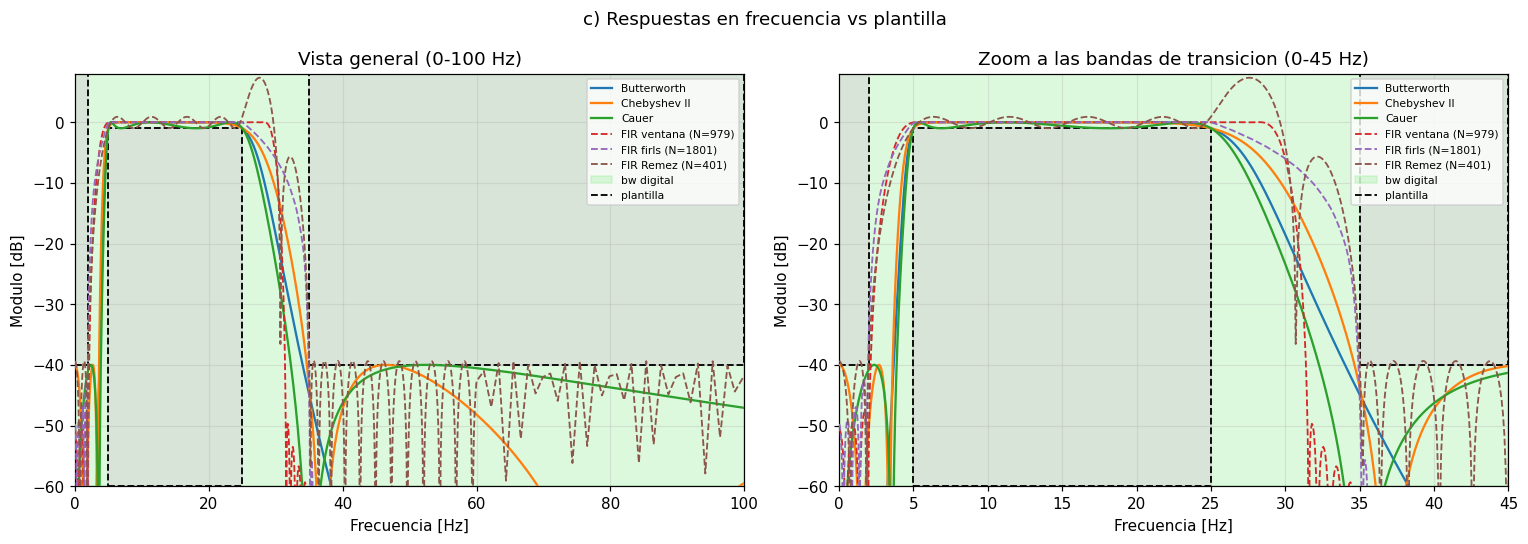

In [25]:
wmalla = np.unique(np.concatenate([
    np.logspace(-2, np.log10(60), 4000),
    np.linspace(60, nyq_frec, 400)]))

iir = [('Butterworth', sos_butter, 'C0'),
       ('Chebyshev II', sos_cheby2, 'C1'),
       ('Cauer',        sos_cauer,  'C2')]
fir = [('FIR ventana (N=%d)' % N_win,   b_win,   'C3'),
       ('FIR firls (N=%d)'   % N_ls,    b_ls,    'C4'),
       ('FIR Remez (N=%d)'   % N_remez, b_remez, 'C5')]

YT = 8
def dibujar_plantilla(ax, fmax):
    ax.fill_between([0, fmax], -60, YT, color='lightgreen', alpha=0.30, zorder=0)
    zonas = [(0,    ws1,  -atenuacion, YT),
             (wp1,  wp2,  -60,        -ripple),
             (ws2,  fmax, -atenuacion, YT)]
    for x0, x1, y0, y1 in zonas:
        ax.fill_between([x0, x1], y0, y1, color='lightgray', alpha=0.55, zorder=1)
        ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], 'k--', lw=1.2, zorder=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('c) Respuestas en frecuencia vs plantilla')

for ax, fmax, titulo in [(axes[0], 100, 'Vista general (0-100 Hz)'),
                         (axes[1], 45,  'Zoom a las bandas de transicion (0-45 Hz)')]:
    dibujar_plantilla(ax, fmax)
    for nombre, sos, c in iir:
        w, H = sig.sosfreqz(sos, worN=wmalla, fs=fs)
        ax.plot(w, 2*20*np.log10(np.abs(H)+1e-18), color=c, lw=1.5, zorder=5, label=nombre)
    for nombre, b, c in fir:
        w, H = sig.freqz(b, 1, worN=wmalla, fs=fs)
        ax.plot(w, 20*np.log10(np.abs(H)+1e-18), color=c, lw=1.2, ls='--', zorder=5, label=nombre)
    ax.fill_between([], [], color='lightgreen', alpha=0.30, label='bw digital')
    ax.plot([], [], 'k--', lw=1.2, label='plantilla')
    ax.set(xlabel='Frecuencia [Hz]', ylabel='Modulo [dB]', xlim=(0, fmax), ylim=(-60, YT))
    ax.set_title(titulo); ax.grid(alpha=0.3); ax.legend(fontsize=7, loc='upper right')

plt.tight_layout(); plt.show()


### Comparacion de los filtros disenados

| Filtro | Tipo | Orden / taps | Demora | Cumple plantilla |
|:--|:--|:--:|:--:|:--:|
| Butterworth | IIR, max. planicidad | ~16 | 0 (fase cero) | ✔ |
| Chebyshev II | IIR | ~8 | 0 | ✔ |
| Cauer / eliptico | IIR | ~6 | 0 | ✔ (orden minimo) |
| FIR ventana (Kaiser) | FIR | 979 | 0.49 s | ✔ |
| FIR firls (rampa) | FIR | 1801 | 0.90 s | ✔ |
| FIR Parks-McClellan | FIR | 401 | 0.20 s | △ (lobulo en transicion) |

Conclusion de diseno.
- Los IIR cumplen con ordenes muy bajos (6-16) y, via `sosfiltfilt`, sin distorsion de fase. El
  Cauer es el de orden minimo; Butterworth el mas plano en la banda de paso.
- El FIR de ventana es el mas robusto: ventanea la respuesta ideal, por lo que su ganancia nunca
  supera 0 dB en ninguna banda.
- firls y Remez tienen un detalle importante: las bandas de transicion quedan *libres* y, al
  subir el orden, sobre-oscilan ahi (firls llega a +49 dB y Remez a +46 dB en ~30 Hz si no se las
  controla). Eso amplifica el ruido del ECG en esa zona. En `firls` se corrige especificando las
  transiciones como rampas; en `Remez`, por el desbalance de anchos de transicion (3 vs 10 Hz),
  no se puede eliminar del todo el lobulo y se toma el mejor compromiso.
- Por eso, para el filtrado del punto d) se usa el FIR de ventana (junto con los IIR), que es el
  que se comporta bien en todo el espectro.

## d) Evaluacion del rendimiento

Se aplican los filtros al registro completo y se inspeccionan dos tipos de regiones:
1. Con ruido interferente (durante el esfuerzo, minutos 5 / 12 / 15) -> verificar que se suprime.
2. Sin ruido interferente (inicio del registro, en reposo) -> verificar que el filtro es *inocuo*.

Se comparan dos IIR (Butterworth y Cauer, fase cero con `sosfiltfilt`) y el FIR de ventana (con
`lfilter`, compensando su demora al graficar). Se usa el FIR de ventana porque firls/Remez amplifican
el ruido en la transicion (ver punto c). Los tres se superponen, confirmando que cumplen la misma
plantilla.

In [26]:
print('Filtrando con IIR (sosfiltfilt)...')
ecg_butt  = sig.sosfiltfilt(sos_butter, ecg_lead)
ecg_cauer = sig.sosfiltfilt(sos_cauer,  ecg_lead)

print('Filtrando con FIR de ventana...')
ecg_fir = sig.lfilter(b_win, 1, ecg_lead)
demora  = demora_win
print('Listo.')


Filtrando con IIR (sosfiltfilt)...
Filtrando con FIR de ventana...
Listo.


In [27]:
def plot_region(ii, titulo):
    i0 = int(max(0, ii[0])); i1 = int(min(cant_muestras, ii[1]))
    zoom = np.arange(i0, i1, dtype=int)
    zf   = zoom + demora
    ok   = zf < cant_muestras

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(zoom, ecg_lead[zoom],      color='0.6', lw=2.2, alpha=0.6, label='ECG original')
    ax.plot(zoom, ecg_butt[zoom],      color='C0',  lw=1.3,            label='Butterworth (IIR)')
    ax.plot(zoom, ecg_cauer[zoom],     color='C2',  lw=1.3,            label='Cauer (IIR)')
    ax.plot(zoom[ok], ecg_fir[zf[ok]], color='C3',  lw=1.1, ls='--',   label='FIR ventana')
    ax.set(title=titulo, xlabel='Muestras (#)', ylabel='Adimensional')
    ax.set_yticks(()); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()


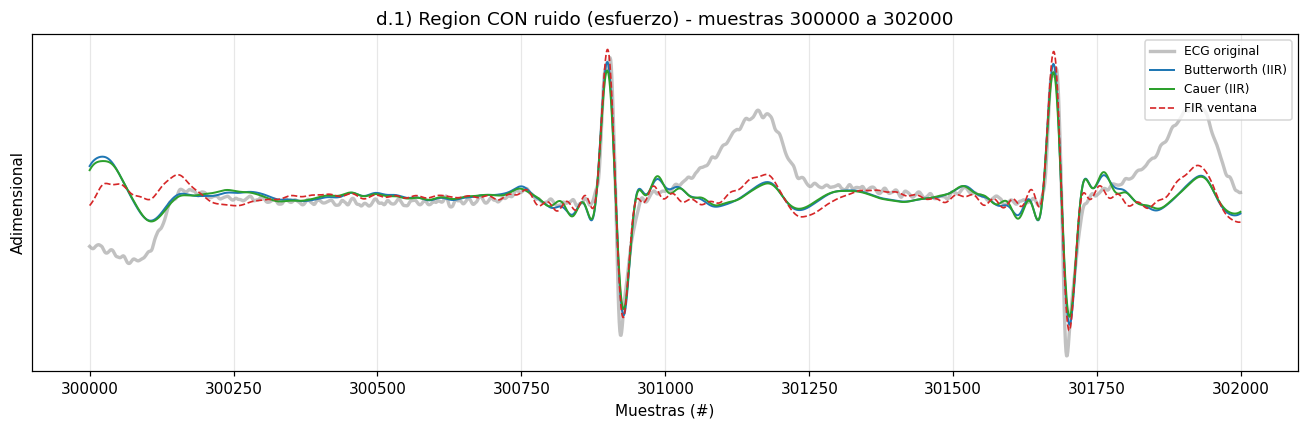

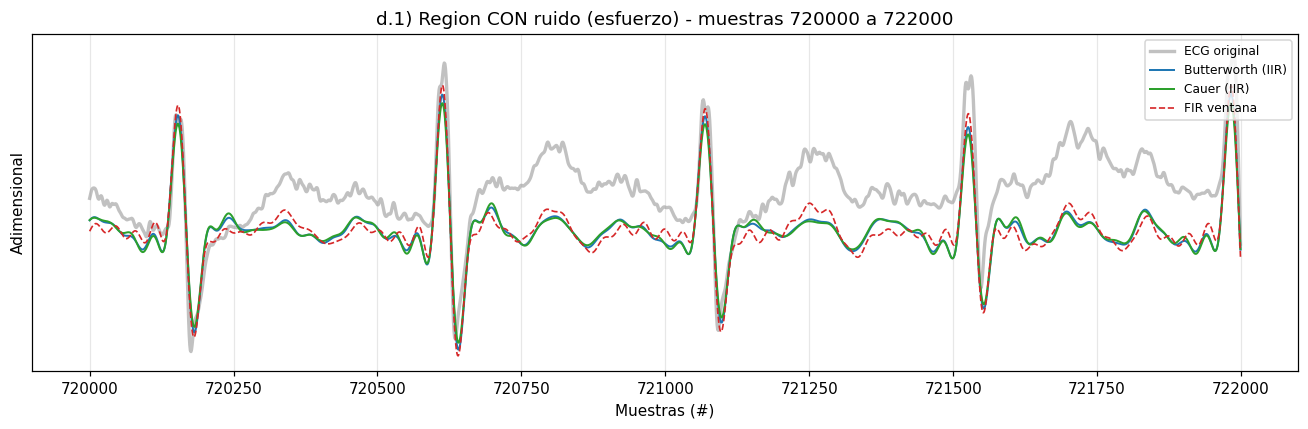

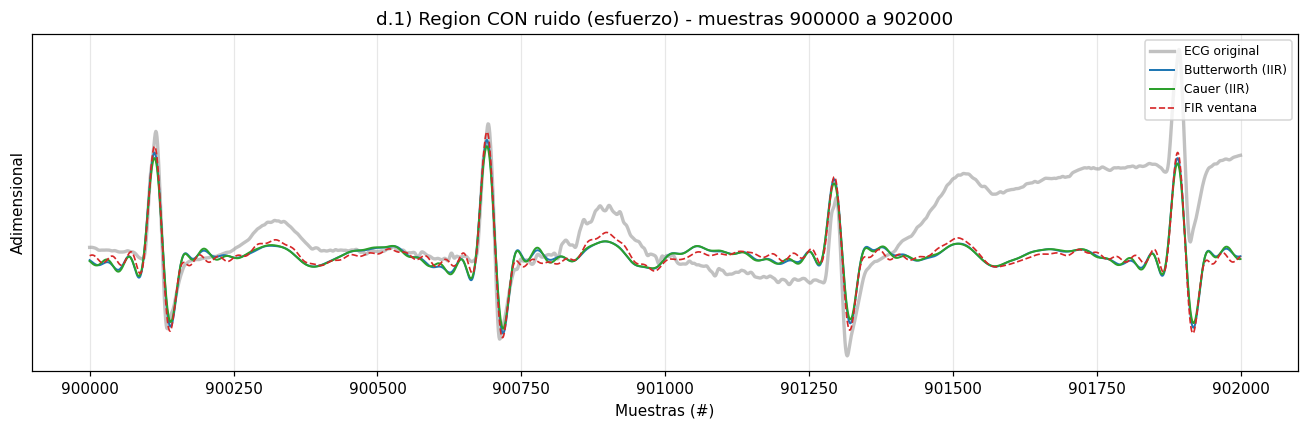

In [28]:
regs_con_ruido = (
    [int( 5 * 60 * fs), int( 5 * 60 * fs) + 2000],
    [int(12 * 60 * fs), int(12 * 60 * fs) + 2000],
    [int(15 * 60 * fs), int(15 * 60 * fs) + 2000],
)
for ii in regs_con_ruido:
    plot_region(ii, f'd.1) Region CON ruido (esfuerzo) - muestras {ii[0]} a {ii[1]}')


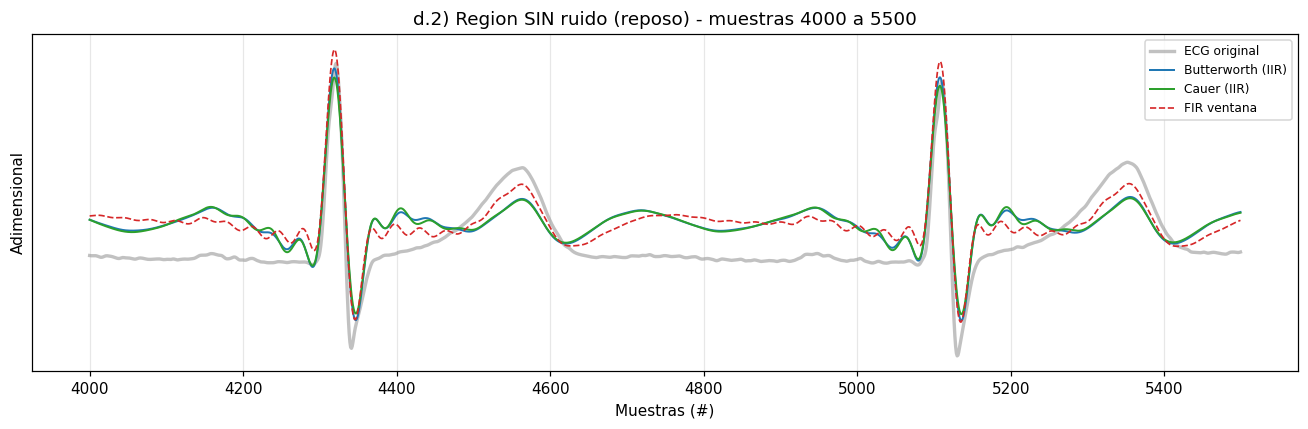

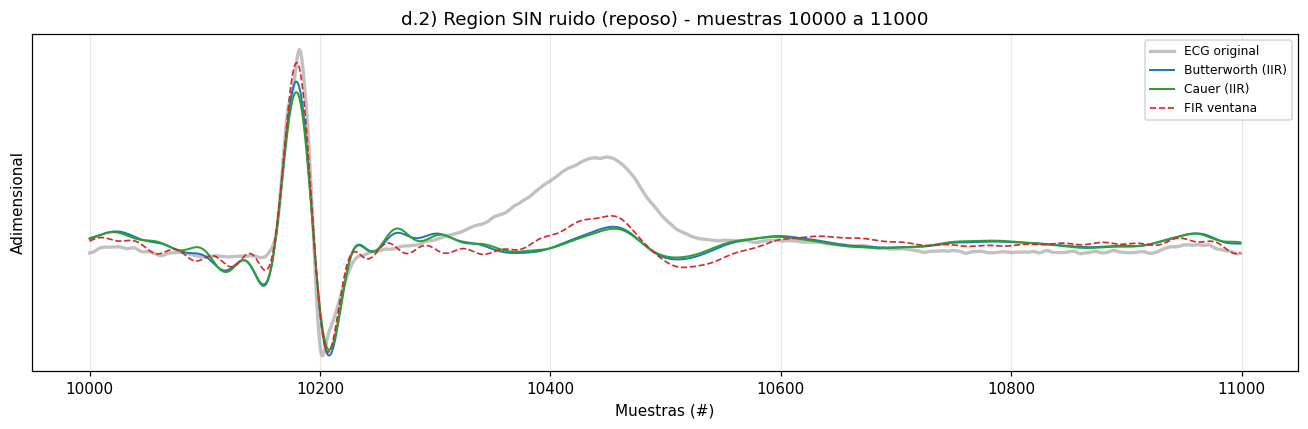

In [29]:
regs_sin_ruido = (
    [4000,  5500],
    [10000, 11000],
)
for ii in regs_sin_ruido:
    plot_region(ii, f'd.2) Region SIN ruido (reposo) - muestras {int(ii[0])} a {int(ii[1])}')


### Conclusiones de la evaluacion

1. Filtra las interferencias (d.1). En las regiones de esfuerzo, los filtros eliminan el ruido de
   alta frecuencia y la deriva de linea de base, recuperando latidos limpios sobre un nivel isoelectrico
   plano.

2. Es inocuo donde no hay ruido (d.2). En las regiones limpias (reposo), los filtros se superponen
   al ECG original sin introducir oscilaciones. Con `wp1 = 5 Hz` y `wp2 = 25 Hz` la linea de base queda
   muy plana y los trazos suaves, al precio de atenuar levemente las ondas lentas (P, T) y de redondear
   las componentes mas rapidas del QRS.

3. IIR vs FIR. Butterworth y Cauer (fase cero, orden 6-16) dan el mejor compromiso. El FIR de ventana
   logra el mismo filtrado con fase lineal exacta, a costa de ~0.5 s de demora (compensable). Se evita
   usar firls/Remez en el filtrado porque amplifican el ruido en la transicion si no se los controla.

## Bonus - Filtrado de una senal de voz

Senal propuesta: registro de audio de voz (`prueba psd.wav`), del repositorio TS5 => https://github.com/marianux/pdstestbench/blob/master/prueba%20psd.wav

Audio: fs=48000 Hz,  N=144000 muestras,  duracion=3.00 s,  Nyquist=24000 Hz


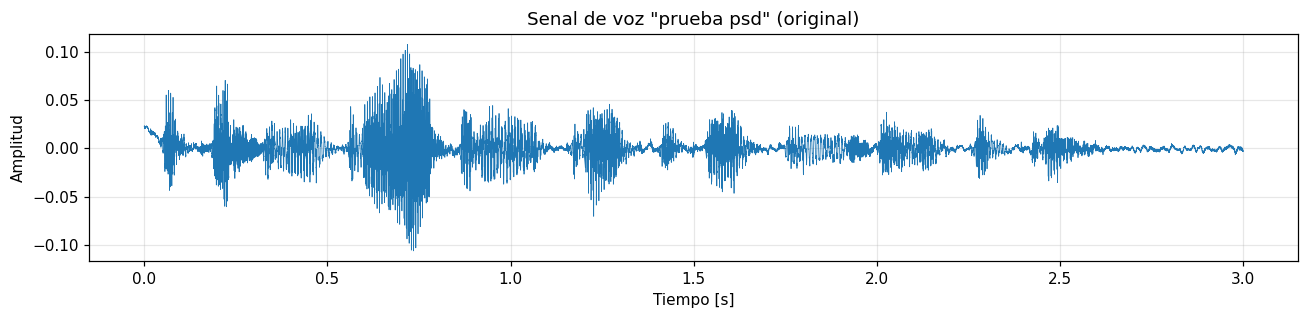

In [30]:
import scipy.io.wavfile as wavio

fs_v, voz = wavio.read('prueba psd.wav')
voz = voz.astype(float)
voz = voz - voz.mean()
Nv  = len(voz)
tv  = np.arange(Nv) / fs_v
nyq_v = fs_v / 2

print(f'Audio: fs={fs_v} Hz,  N={Nv} muestras,  duracion={Nv/fs_v:.2f} s,  Nyquist={nyq_v:.0f} Hz')

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(tv, voz, lw=0.5, color='C0')
ax.set(title='Senal de voz "prueba psd" (original)', xlabel='Tiempo [s]', ylabel='Amplitud')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


BW 90% de potencia :   1137 Hz
BW 95% de potencia :   1172 Hz
BW 99% de potencia :   2637 Hz


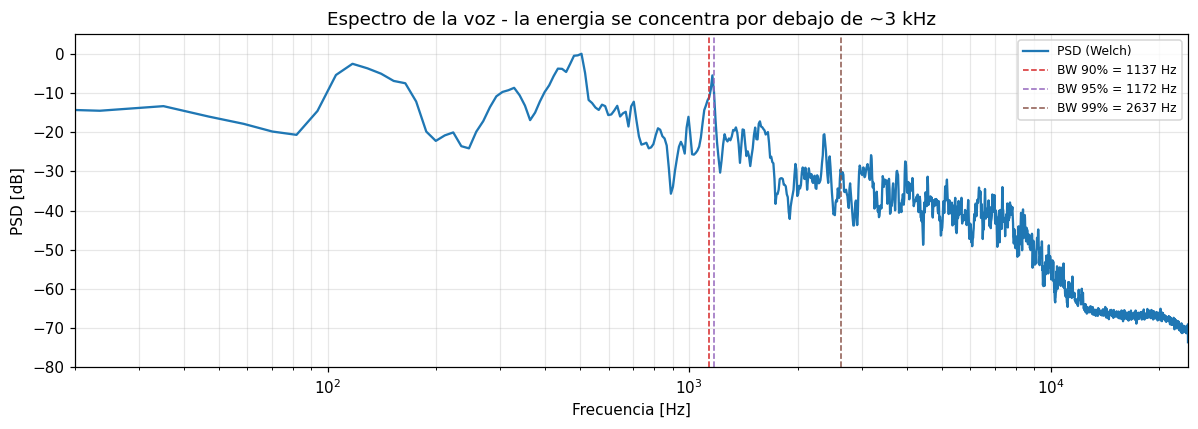

In [31]:
fw, Pw = sig.welch(voz, fs=fs_v, window='hann', nperseg=4096, noverlap=2048)
Pc = np.cumsum(Pw) / np.sum(Pw)
bw = {p: fw[np.searchsorted(Pc, p)] for p in (0.90, 0.95, 0.99)}
for p, f_bw in bw.items():
    print(f'BW {int(p*100)}% de potencia : {f_bw:6.0f} Hz')

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogx(fw, 10*np.log10(Pw/Pw.max()+1e-18), color='C0', label='PSD (Welch)')
for p, c in zip((0.90, 0.95, 0.99), ('C3','C4','C5')):
    ax.axvline(bw[p], color=c, ls='--', lw=1, label=f'BW {int(p*100)}% = {bw[p]:.0f} Hz')
ax.set(title='Espectro de la voz - la energia se concentra por debajo de ~3 kHz',
       xlabel='Frecuencia [Hz]', ylabel='PSD [dB]', xlim=(20, nyq_v), ylim=(-80, 5))
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()


### Plantilla para la voz - banda telefonica

El espectro confirma que el 99 % de la potencia esta por debajo de ~2.6 kHz. Se adopta la clasica
banda telefonica [300, 3400] Hz, que es el estandar de inteligibilidad de la voz:

| Parametro | Valor | Justificacion |
|:--|:--:|:--|
| `ws1` | 100 Hz | Stopband inferior: elimina el zumbido de red (50/100 Hz) y el rumble. |
| `wp1` | 300 Hz | Inicio de banda de paso (banda telefonica). |
| `wp2` | 3400 Hz | Fin de banda de paso: cubre el BW-99% y los formantes principales. |
| `ws2` | 5000 Hz | Stopband superior: elimina el hiss de alta frecuencia. |
| `gpass` / `gstop` | 1 / 40 dB | Igual que en el ECG. |

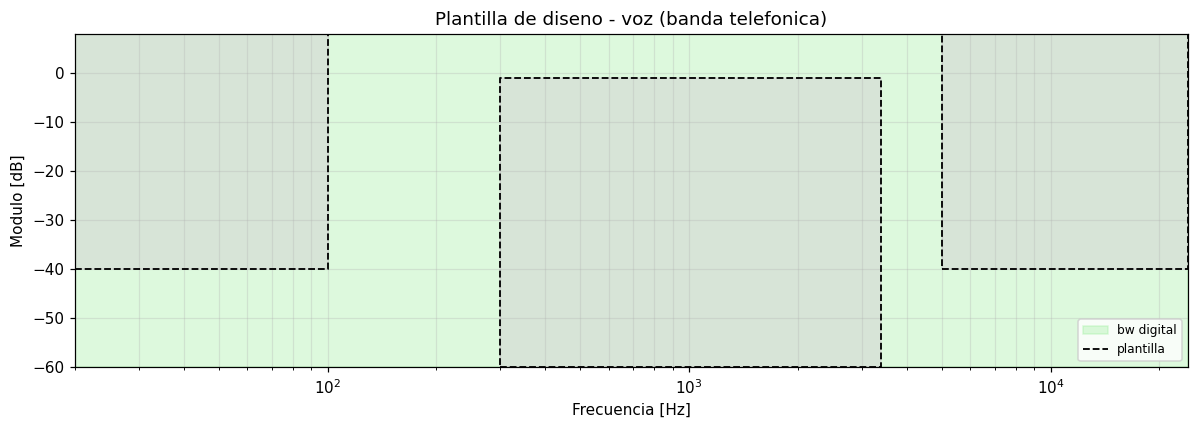

In [32]:
ws1_v, wp1_v, wp2_v, ws2_v = 100.0, 300.0, 3400.0, 5000.0
gp_v, gs_v = 1, 40

A = np.abs(voz).max()
rng_v = np.random.default_rng(0)
hum  = 0.25 * A * (np.sin(2*np.pi*50*tv) + 0.5*np.sin(2*np.pi*100*tv))
hiss = sig.sosfiltfilt(sig.butter(6, 5000/nyq_v, 'high', output='sos'),
                       rng_v.standard_normal(Nv))
hiss = 0.15 * A * hiss / hiss.std()
voz_cont = voz + hum + hiss

fig, ax = plt.subplots(figsize=(11, 4))
YT, fmin = 8, 20
ax.fill_between([fmin, nyq_v], -60, YT, color='lightgreen', alpha=0.30, zorder=0)
for x0, x1, y0, y1 in [(fmin, ws1_v, -gs_v, YT), (wp1_v, wp2_v, -60, -gp_v), (ws2_v, nyq_v, -gs_v, YT)]:
    ax.fill_between([x0, x1], y0, y1, color='lightgray', alpha=0.55, zorder=1)
    ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], 'k--', lw=1.2, zorder=2)
ax.fill_between([], [], color='lightgreen', alpha=0.30, label='bw digital')
ax.plot([], [], 'k--', lw=1.2, label='plantilla')
ax.set_xscale('log')
ax.set(title='Plantilla de diseno - voz (banda telefonica)', xlabel='Frecuencia [Hz]',
       ylabel='Modulo [dB]', xlim=(fmin, nyq_v), ylim=(-60, YT))
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()


IIR Butterworth: orden 16   |   IIR Cauer: orden 6
FIR ventana: N=705 (demora 7.3 ms)   |   FIR firls: N=2001 (demora 20.8 ms)


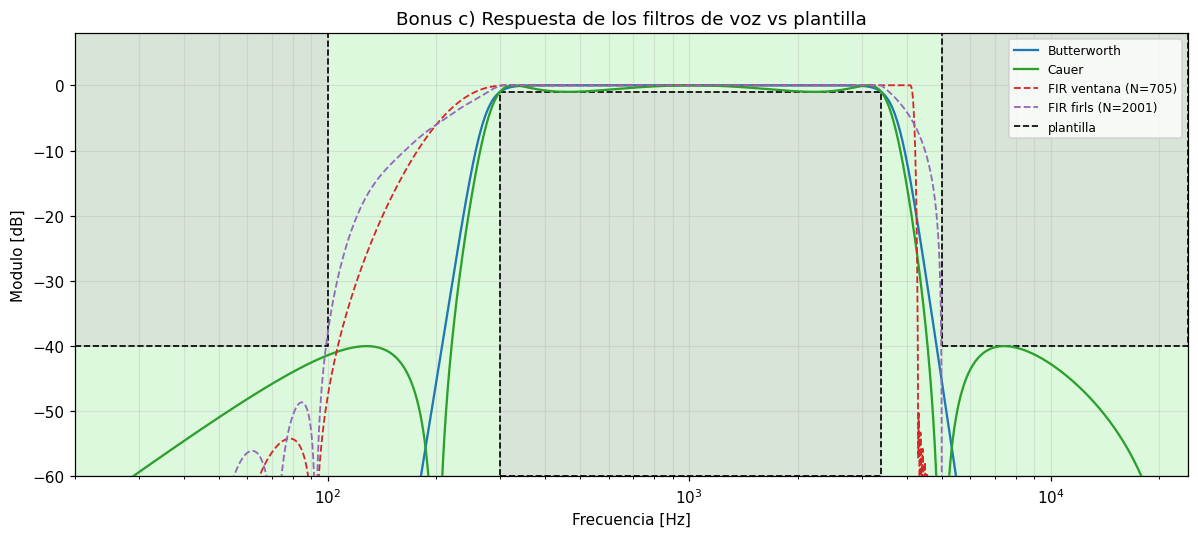

In [33]:
wp_v, ws_v = [wp1_v, wp2_v], [ws1_v, ws2_v]
sos_butt_v = sig.iirdesign(wp_v, ws_v, gp_v/2, gs_v/2, ftype='butter', output='sos', fs=fs_v)
sos_cauer_v= sig.iirdesign(wp_v, ws_v, gp_v/2, gs_v/2, ftype='ellip',  output='sos', fs=fs_v)

trans_v = (wp1_v - ws1_v) / nyq_v
Nwin_v, beta_v = sig.kaiserord(50, trans_v); Nwin_v |= 1
b_win_v = sig.firwin(Nwin_v, [(ws1_v+wp1_v)/2, (wp2_v+ws2_v)/2],
                     window=('kaiser', beta_v), pass_zero=False, fs=fs_v)
bands_v = [0, ws1_v, ws1_v, wp1_v, wp1_v, wp2_v, wp2_v, ws2_v, ws2_v, nyq_v]
des_v   = [0, 0,     0,     1,     1,     1,     1,     0,     0,     0]
Nls_v = 2001
b_ls_v = sig.firls(Nls_v, bands_v, des_v, fs=fs_v)

print(f'IIR Butterworth: orden {sos_butt_v.shape[0]*2}   |   IIR Cauer: orden {sos_cauer_v.shape[0]*2}')
print(f'FIR ventana: N={Nwin_v} (demora {(Nwin_v-1)//2/fs_v*1000:.1f} ms)   |   FIR firls: N={Nls_v} (demora {(Nls_v-1)//2/fs_v*1000:.1f} ms)')

wmv = np.unique(np.concatenate([np.logspace(np.log10(20), np.log10(8000), 4000),
                                np.linspace(8000, nyq_v, 300)]))
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between([20, nyq_v], -60, 8, color='lightgreen', alpha=0.30, zorder=0)
for x0,x1,y0,y1 in [(20,ws1_v,-gs_v,8),(wp1_v,wp2_v,-60,-gp_v),(ws2_v,nyq_v,-gs_v,8)]:
    ax.fill_between([x0,x1],y0,y1,color='lightgray',alpha=0.55,zorder=1)
    ax.plot([x0,x1,x1,x0,x0],[y0,y0,y1,y1,y0],'k--',lw=1.1,zorder=2)
for nm, s, c in [('Butterworth',sos_butt_v,'C0'),('Cauer',sos_cauer_v,'C2')]:
    w,H=sig.sosfreqz(s,worN=wmv,fs=fs_v); ax.semilogx(w,2*20*np.log10(np.abs(H)+1e-18),color=c,lw=1.5,zorder=5,label=nm)
for nm, b, c in [(f'FIR ventana (N={Nwin_v})',b_win_v,'C3'),(f'FIR firls (N={Nls_v})',b_ls_v,'C4')]:
    w,H=sig.freqz(b,1,worN=wmv,fs=fs_v); ax.semilogx(w,20*np.log10(np.abs(H)+1e-18),color=c,lw=1.2,ls='--',zorder=5,label=nm)
ax.plot([],[],'k--',lw=1.1,label='plantilla')
ax.set(title='Bonus c) Respuesta de los filtros de voz vs plantilla', xlabel='Frecuencia [Hz]',
       ylabel='Modulo [dB]', xlim=(20, nyq_v), ylim=(-60, 8))
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8, loc='upper right'); plt.tight_layout(); plt.show()


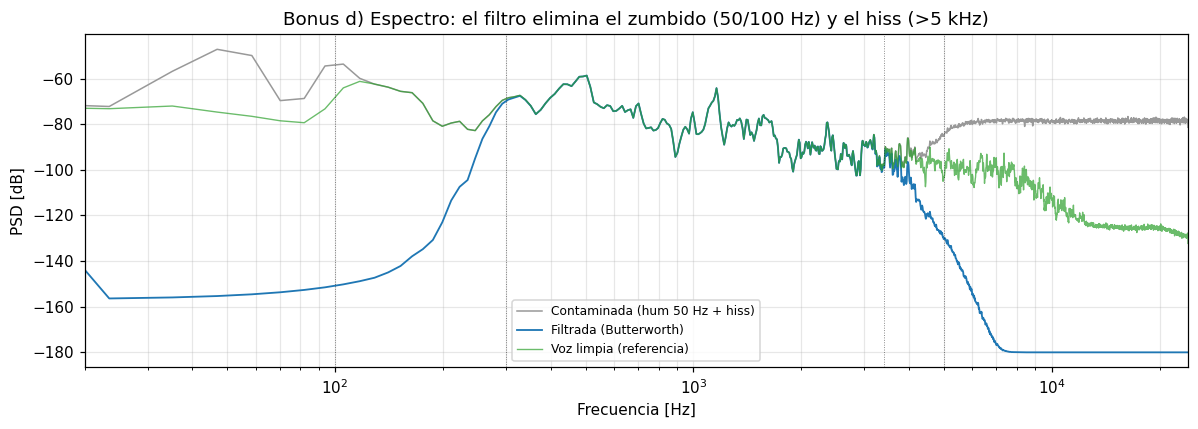

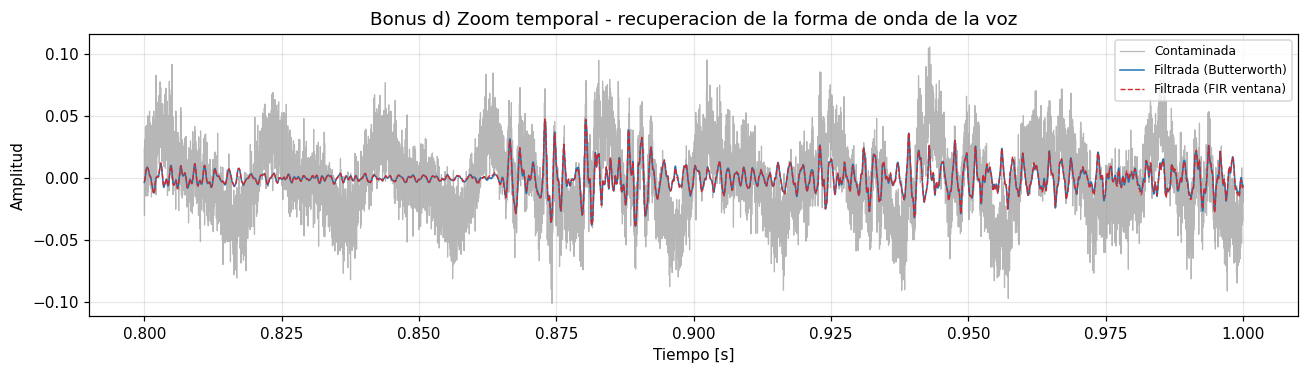

In [34]:
voz_butt = sig.sosfiltfilt(sos_butt_v, voz_cont)
voz_win  = sig.lfilter(b_win_v, 1, voz_cont)
dem_v    = (Nwin_v - 1) // 2

f1,P1 = sig.welch(voz_cont, fs=fs_v, nperseg=4096)
f2,P2 = sig.welch(voz_butt, fs=fs_v, nperseg=4096)
f0,P0 = sig.welch(voz,      fs=fs_v, nperseg=4096)
fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogx(f1,10*np.log10(P1+1e-18),color='0.6',lw=1.0,label='Contaminada (hum 50 Hz + hiss)')
ax.semilogx(f2,10*np.log10(P2+1e-18),color='C0',lw=1.2,label='Filtrada (Butterworth)')
ax.semilogx(f0,10*np.log10(P0+1e-18),color='C2',lw=0.9,alpha=0.7,label='Voz limpia (referencia)')
for fb in (ws1_v,wp1_v,wp2_v,ws2_v): ax.axvline(fb,color='k',ls=':',lw=0.6,alpha=0.5)
ax.set(title='Bonus d) Espectro: el filtro elimina el zumbido (50/100 Hz) y el hiss (>5 kHz)',
       xlabel='Frecuencia [Hz]', ylabel='PSD [dB]', xlim=(20, nyq_v))
ax.grid(alpha=0.3, which='both'); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

i0,i1 = int(0.8*fs_v), int(1.0*fs_v)
z = np.arange(i0,i1); zf = z + dem_v; ok = zf < Nv
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(z/fs_v, voz_cont[z], color='0.6', lw=0.8, alpha=0.7, label='Contaminada')
ax.plot(z/fs_v, voz_butt[z], color='C0', lw=1.0, label='Filtrada (Butterworth)')
ax.plot(z[ok]/fs_v, voz_win[zf[ok]], color='C3', lw=0.9, ls='--', label='Filtrada (FIR ventana)')
ax.set(title='Bonus d) Zoom temporal - recuperacion de la forma de onda de la voz',
       xlabel='Tiempo [s]', ylabel='Amplitud'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Conclusiones del bonus

- El mismo flujo de diseno del ECG se aplica sin cambios a la voz: solo cambian las frecuencias de la
  plantilla (aca una banda telefonica [300, 3400] Hz a $f_s = 48$ kHz).
- El pasa-banda elimina el zumbido de red de 50/100 Hz (interferencia de baja frecuencia, analoga a la
  deriva del ECG) y el hiss de alta frecuencia (analogo al ruido muscular): en el espectro filtrado
  desaparecen el pico de 50 Hz y la cola de ruido por encima de 5 kHz, recuperando la curva de la voz limpia.
- Igual que en el punto c), `firls` necesita transiciones en rampa para no sobre-oscilar, y el FIR de
  ventana y los IIR (Butterworth / Cauer) son los mas robustos.